# Credit Risk Modelling — Credit Card Default

### Objective
Built a credit risk framework using:
- Logistic Regression
- XGBoost
- Probability of Default (PD)
- Exposure at Default (EAD)
- Assumed Loss Given Default (LGD)
- Expected Credit Loss (ECL)

**Important modelling assumptions**
- credit_card_default is the target variable.
- EAD is approximated as credit_limit × credit_limit_used(%).
- The dataset does not contain recovery information, so LGD is assumed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve)
from xgboost import XGBClassifier
pd.set_option('display.max_columns', None)


In [49]:
df = pd.read_csv(r"C:\Users\Mikey\Downloads\train.csv")
df.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe(include='all').T)


Missing values:
customer_id                  0
name                         0
age                          0
gender                       0
owns_car                   547
owns_house                   0
no_of_children             774
net_yearly_income            0
no_of_days_employed        463
occupation_type              0
total_family_members        83
migrant_worker              87
yearly_debt_payments        95
credit_limit                 0
credit_limit_used(%)         0
credit_score                 8
prev_defaults                0
default_in_last_6months      0
credit_card_default          0
dtype: int64

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,45528,45528,CST_115179,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,45528,4010,Jonathan,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,45528.0,NaN,NaN,NaN,38.993411,9.54399,23.0,31.0,39.0,47.0,55.0
gender,45528,3,F,29957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owns_car,44981,2,N,29743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owns_house,45528,2,Y,31642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_children,44754.0,NaN,NaN,NaN,0.420655,0.724097,0.0,0.0,0.0,1.0,9.0
net_yearly_income,45528.0,NaN,NaN,NaN,200655.622249,669074.034607,27170.61,126345.835,171714.91,240603.76,140759012.73
no_of_days_employed,45065.0,NaN,NaN,NaN,67609.289293,139323.524434,2.0,936.0,2224.0,5817.0,365252.0
occupation_type,45528,19,Unknown,14299,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
print(df['credit_card_default'].value_counts())

default_rate = df['credit_card_default'].mean()
print(f"Default rate: {round(default_rate * 100, 2)}%")


credit_card_default
0    41831
1     3697
Name: count, dtype: int64
Default rate: 8.12%


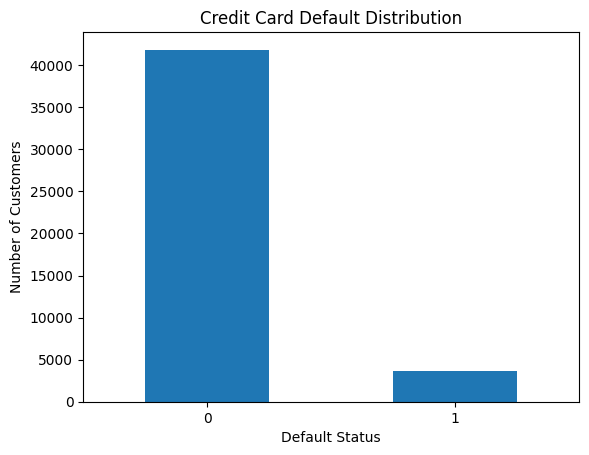

In [52]:
df['credit_card_default'].value_counts().plot(kind='bar')

plt.title("Credit Card Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()


In [ ]:
target = 'credit_card_default'

numerical_columns = [
    'age',
    'net_yearly_income',
    'no_of_days_employed',
    'total_family_members',
    'credit_score',
    'credit_limit',
    'credit_limit_used(%)',
    'prev_defaults',
    'default_in_last_6months',
    'yearly_debt_payments']

categorical_columns = ['occupation_type','owns_car','owns_house','migrant_worker']

Numerical columns:
['age', 'net_yearly_income', 'no_of_days_employed', 'total_family_members', 'credit_score', 'credit_limit', 'credit_limit_used(%)', 'prev_defaults', 'default_in_last_6months', 'yearly_debt_payments']

Categorical columns:
['occupation_type', 'owns_car', 'owns_house', 'migrant_worker']


In [86]:
# Numerical variables: replace missing values with the median.
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical variables: replace missing values with the mode.
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after cleaning:", df.isnull().sum().sum())


Total missing values after cleaning: 774


In [ ]:
print("Default rate by previous defaults:")
display(df.groupby('prev_defaults')['credit_card_default'].mean().reset_index(name='default_rate'))

print("\nDefault rate by default in last 6 months:")
display(df.groupby('default_in_last_6months')['credit_card_default'].mean().reset_index(name='default_rate'))

Default rate by previous defaults:


,prev_defaults,default_rate
0,0,0.028542
1,1,1.000000
2,2,1.000000



Default rate by default in last 6 months:


,default_in_last_6months,default_rate
0,0,0.032295
1,1,1.000000


credit_score_band
<500       1.000000
500-600    1.000000
600-700    0.201993
700-800    0.000072
800+       0.000000
Name: credit_card_default, dtype: float64

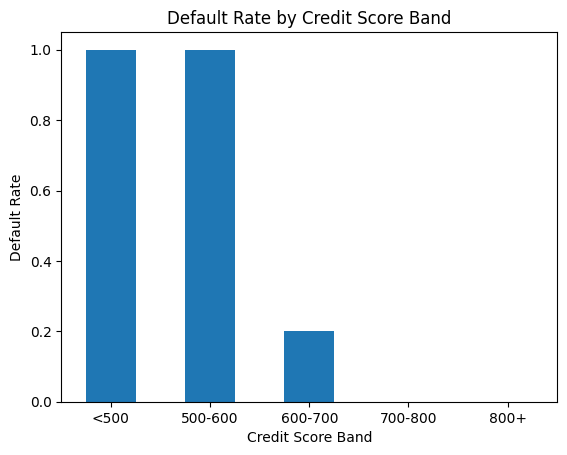

In [88]:
df['credit_score_band'] = pd.cut(df['credit_score'],
    bins=[0, 500, 600, 700, 800, 1000],
    labels=['<500', '500-600', '600-700', '700-800', '800+'],
    include_lowest=True)

score_default = (df.groupby('credit_score_band', observed=False)['credit_card_default'].mean())

display(score_default)
score_default.plot(kind='bar')
plt.title("Default Rate by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()


utilization_band
0-20%     0.000000
20-40%    0.000000
40-60%    0.000000
60-80%    0.137241
80%+      0.229984
Name: credit_card_default, dtype: float64

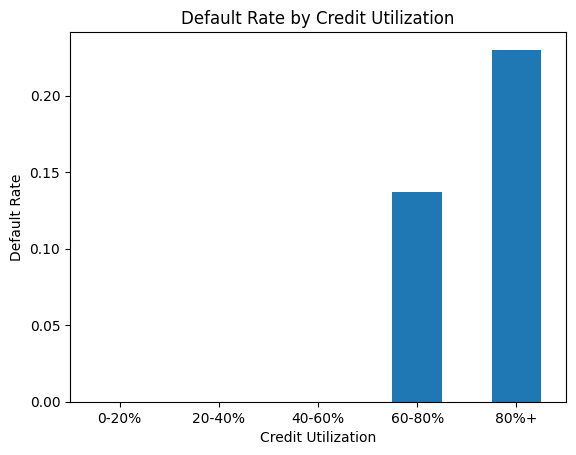

In [91]:
df['utilization_band'] = pd.cut(df['credit_limit_used(%)'],bins=[-np.inf, 20, 40, 60, 80, np.inf],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80%+'])

util_default = (df.groupby('utilization_band', observed=False)['credit_card_default'].mean())

display(util_default)
util_default.plot(kind='bar')
plt.title("Default Rate by Credit Utilization")
plt.xlabel("Credit Utilization")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()


In [ ]:
features = numerical_columns + categorical_columns
model_df = df[features + [target]].copy()
model_df.head()

,age,net_yearly_income,no_of_days_employed,total_family_members,credit_score,credit_limit,credit_limit_used(%),prev_defaults,default_in_last_6months,yearly_debt_payments,occupation_type,owns_car,owns_house,migrant_worker,credit_card_default
0,46,107934.04,612.0,1.0,544.0,18690.93,73,2,1,33070.28,Unknown,N,Y,1.0,1
1,29,109862.62,2771.0,2.0,857.0,37745.19,52,0,0,15329.53,Laborers,N,Y,0.0,0
2,37,230153.17,204.0,2.0,650.0,41598.36,43,0,0,48416.60,Laborers,N,Y,0.0,0
3,39,122325.82,11941.0,2.0,754.0,32627.76,20,0,0,22574.36,Core staff,N,Y,0.0,0
4,46,387286.00,1459.0,1.0,927.0,52950.64,75,0,0,38282.95,Core staff,Y,Y,0.0,0


In [ ]:
model_df = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True)

print("Final modelling shape:", model_df.shape)
model_df.head()


Final modelling shape: (45528, 32)


,age,net_yearly_income,no_of_days_employed,total_family_members,credit_score,credit_limit,credit_limit_used(%),prev_defaults,default_in_last_6months,yearly_debt_payments,credit_card_default,occupation_type_Cleaning staff,occupation_type_Cooking staff,occupation_type_Core staff,occupation_type_Drivers,occupation_type_HR staff,occupation_type_High skill tech staff,occupation_type_IT staff,occupation_type_Laborers,occupation_type_Low-skill Laborers,occupation_type_Managers,occupation_type_Medicine staff,occupation_type_Private service staff,occupation_type_Realty agents,occupation_type_Sales staff,occupation_type_Secretaries,occupation_type_Security staff,occupation_type_Unknown,occupation_type_Waiters/barmen staff,owns_car_Y,owns_house_Y,migrant_worker_1.0
0,46,107934.04,612.0,1.0,544.0,18690.93,73,2,1,33070.28,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,29,109862.62,2771.0,2.0,857.0,37745.19,52,0,0,15329.53,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
2,37,230153.17,204.0,2.0,650.0,41598.36,43,0,0,48416.60,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
3,39,122325.82,11941.0,2.0,754.0,32627.76,20,0,0,22574.36,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,46,387286.00,1459.0,1.0,927.0,52950.64,75,0,0,38282.95,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False


In [61]:
X = model_df.drop(columns=[target])
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (45528, 31)
y shape: (45528,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


Training observations: 34146
Testing observations: 11382


In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [64]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled,y_train)

print("Logistic Regression model trained.")


Logistic Regression model trained.


In [65]:
log_pd = log_model.predict_proba(X_test_scaled)[:, 1]
log_pred = log_model.predict(X_test_scaled)

In [66]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

log_accuracy = accuracy_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_pd)

print("Accuracy:", round(log_accuracy, 4))
print("ROC-AUC:", round(log_auc, 4))


Confusion Matrix:
[[10424    34]
 [  194   730]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10458
           1       0.96      0.79      0.86       924

    accuracy                           0.98     11382
   macro avg       0.97      0.89      0.93     11382
weighted avg       0.98      0.98      0.98     11382

Accuracy: 0.98
ROC-AUC: 0.9939


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss')

xgb_model.fit(X_train,y_train)

XGBoost model trained.


In [68]:
xgb_pd = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

In [69]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pd)

print("Accuracy:", round(xgb_accuracy, 4))
print("ROC-AUC:", round(xgb_auc, 4))


Confusion Matrix:
[[10446    12]
 [  206   718]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10458
           1       0.98      0.78      0.87       924

    accuracy                           0.98     11382
   macro avg       0.98      0.89      0.93     11382
weighted avg       0.98      0.98      0.98     11382

Accuracy: 0.9808
ROC-AUC: 0.9958


In [70]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [log_accuracy, xgb_accuracy],
    'ROC-AUC': [log_auc, xgb_auc]})

display(model_comparison)


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.979968,0.993941
1,XGBoost,0.980847,0.995828


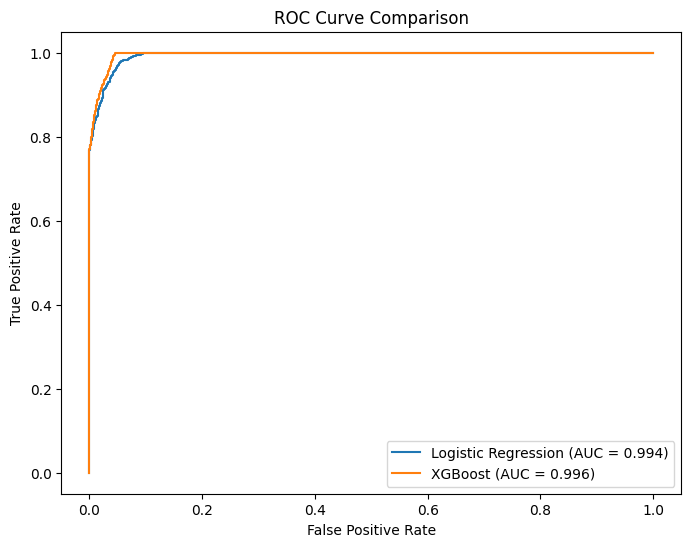

In [92]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_pd)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pd)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr,log_tpr,label=f"Logistic Regression (AUC = {log_auc:.3f})")

plt.plot(xgb_fpr,xgb_tpr,label=f"XGBoost (AUC = {xgb_auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
if xgb_auc > log_auc:
    final_pd = xgb_pd
    final_model = 'XGBoost'
else:
    final_pd = log_pd
    final_model = 'Logistic Regression'

print("Final PD model:", final_model)

Final PD model: XGBoost


In [73]:
results = df.loc[X_test.index].copy()

results['PD'] = final_pd

print("Results shape:", results.shape)

display(results[['credit_score','credit_limit','credit_limit_used(%)','credit_card_default','PD']].head(10))


Results shape: (11382, 22)


,credit_score,credit_limit,credit_limit_used(%),credit_card_default,PD
10935,664.0,57914.57,15,0,0.000641
30236,840.0,28482.54,88,0,0.000345
6194,922.0,59411.93,75,0,0.000270
24352,757.0,35101.89,42,0,0.000040
1596,653.0,47316.04,95,0,0.472230
34289,601.0,88948.48,71,1,0.999553
7443,693.0,19944.46,7,0,0.000542
15498,768.0,45727.83,91,0,0.000343
44400,817.0,21795.51,50,0,0.000031
28105,572.0,51018.84,83,1,0.999514


In [74]:
results['EAD'] = (results['credit_limit']* results['credit_limit_used(%)']/ 100)

display(results[['credit_limit','credit_limit_used(%)','EAD']].head(10))


,credit_limit,credit_limit_used(%),EAD
10935,57914.57,15,8687.1855
30236,28482.54,88,25064.6352
6194,59411.93,75,44558.9475
24352,35101.89,42,14742.7938
1596,47316.04,95,44950.2380
34289,88948.48,71,63153.4208
7443,19944.46,7,1396.1122
15498,45727.83,91,41612.3253
44400,21795.51,50,10897.7550
28105,51018.84,83,42345.6372


## LGD assumption

The dataset does not contain recovery amounts, collateral recoveries, or loss-at-default observations.

Therefore, LGD cannot be estimated empirically from this dataset.
For the ECL demonstration, we use an explicit assumption:
**LGD = 45%**
This is an assumption for the project and should not be presented as an estimated value from the dataset.


In [ ]:
LGD_ASSUMPTION = 0.45
results['LGD'] = LGD_ASSUMPTION
print("Assumed LGD:", LGD_ASSUMPTION * 100, "%")

Assumed LGD: 45.0 %


In [ ]:
results['ECL'] = (results['PD']*results['LGD']*results['EAD'])
(results[['PD','LGD','EAD','ECL']].head(10))

,PD,LGD,EAD,ECL
10935,0.000641,0.45,8687.1855,2.504651
30236,0.000345,0.45,25064.6352,3.888060
6194,0.000270,0.45,44558.9475,5.420733
24352,0.000040,0.45,14742.7938,0.265922
1596,0.472230,0.45,44950.2380,9552.086263
34289,0.999553,0.45,63153.4208,28406.343529
7443,0.000542,0.45,1396.1122,0.340414
15498,0.000343,0.45,41612.3253,6.431487
44400,0.000031,0.45,10897.7550,0.150741
28105,0.999514,0.45,42345.6372,19046.284525


In [ ]:
total_ead = results['EAD'].sum()
total_ecl = results['ECL'].sum()
portfolio_ecl_rate = total_ecl / total_ead

print("Total EAD:", round(total_ead, 2))
print("Total ECL:", round(total_ecl, 2))
print("Portfolio ECL rate:", round(portfolio_ecl_rate * 100, 2), "%")

Total EAD: 251421633.12
Total ECL: 14019898.79
Portfolio ECL rate: 5.58 %


In [ ]:
average_pd = results['PD'].mean()
print("Average PD:", round(average_pd * 100, 2), "%")

Average PD: 8.04 %


In [ ]:
score_ecl = (results.groupby('credit_score_band', observed=False).agg(
        customers=('credit_card_default', 'count'),
        total_EAD=('EAD', 'sum'),
        average_PD=('PD', 'mean'),
        total_ECL=('ECL', 'sum')))

score_ecl['ECL_Rate'] = (score_ecl['total_ECL']/ score_ecl['total_EAD'])
display(score_ecl)


,customers,total_EAD,average_PD,total_ECL,ECL_Rate
credit_score_band,,,,,
<500,6,2.164207e+05,0.997310,9.716596e+04,0.448968
500-600,475,1.649386e+07,0.998349,7.410065e+06,0.449262
600-700,2173,5.011151e+07,0.199474,6.494808e+06,0.129607
700-800,3516,7.395388e+07,0.000143,7.227966e+03,0.000098
800+,5212,1.106460e+08,0.000141,1.063162e+04,0.000096


In [ ]:
occupation_ecl = (results.groupby('occupation_type', dropna=False).agg(
    customers=('credit_card_default', 'count'),
    total_EAD=('EAD', 'sum'),
    average_PD=('PD', 'mean'),
    total_ECL=('ECL', 'sum')))

occupation_ecl['ECL_Rate'] = (occupation_ecl['total_ECL']/ occupation_ecl['total_EAD'])

display(occupation_ecl.sort_values('total_ECL', ascending=False))


,customers,total_EAD,average_PD,total_ECL,ECL_Rate
occupation_type,,,,,
Unknown,3565,6.933219e+07,0.066681,3.265721e+06,0.047103
Laborers,2045,4.453046e+07,0.095624,3.070168e+06,0.068945
Sales staff,1160,2.465316e+07,0.092392,1.638472e+06,0.066461
Drivers,643,1.670864e+07,0.123681,1.418335e+06,0.084886
Managers,752,2.577525e+07,0.070286,1.236296e+06,0.047964
Core staff,1054,2.461427e+07,0.058909,9.543949e+05,0.038774
High skill tech staff,438,9.899519e+06,0.075880,5.134339e+05,0.051865
Security staff,278,5.522094e+06,0.102277,3.398407e+05,0.061542
Medicine staff,321,6.472302e+06,0.073342,3.303297e+05,0.051037


,importance
prev_defaults,0.352372
credit_score,0.280448
default_in_last_6months,0.192305
credit_limit_used(%),0.101791
no_of_days_employed,0.007811
occupation_type_Unknown,0.006496
occupation_type_Laborers,0.004538
yearly_debt_payments,0.003972
owns_car_Y,0.003960
net_yearly_income,0.003914


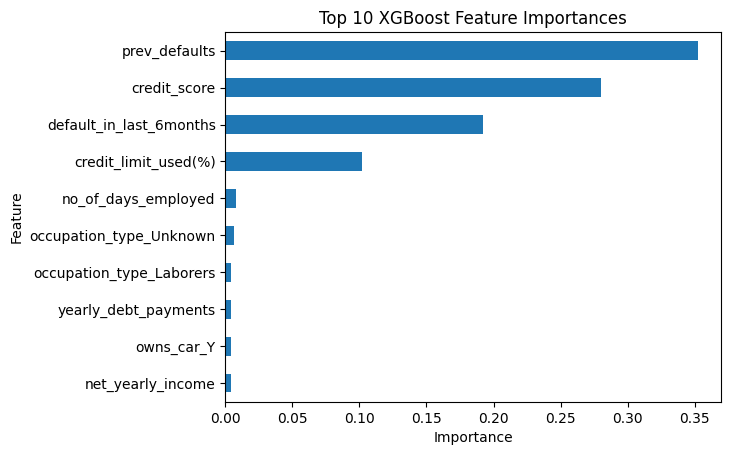

In [ ]:
# Cell 34: XGBoost feature importance

feature_importance = pd.Series(xgb_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)

display(feature_importance.head(10).to_frame('importance'))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
print("----------- CREDIT RISK MODEL SUMMARY ------------")
print("Number of test customers:", len(results))
print("Final PD model:", final_model)
print("Logistic Regression ROC-AUC:",round(log_auc, 4))
print("XGBoost ROC-AUC:",round(xgb_auc, 4))
print("Average PD:",round(average_pd * 100, 2),"%")
print("Total EAD:",round(total_ead, 2))
print("Assumed LGD:",round(LGD_ASSUMPTION * 100, 2),"%")
print("Total ECL:",round(total_ecl, 2))
print("Portfolio ECL Rate:",round(portfolio_ecl_rate * 100, 2),"%")

========== CREDIT RISK MODEL SUMMARY ==========
Number of test customers: 11382
Final PD model: XGBoost
Logistic Regression ROC-AUC: 0.9939
XGBoost ROC-AUC: 0.9958
Average PD: 8.04 %
Total EAD: 251421633.12
Assumed LGD: 45.0 %
Total ECL: 14019898.79
Portfolio ECL Rate: 5.58 %
